In [1]:
import warnings
warnings.filterwarnings("ignore")


In [3]:
import sys
print(sys.executable)

!pip install grakel



C:\ProgramData\anaconda3\python.exe
   ---------------------------------------- 0.0/679.1 kB ? eta -:--:--
   ---------------------------------------- 679.1/679.1 kB 8.9 MB/s eta 0:00:00

   ---------------------------------------- 0/2 [future]
   ---------------------------------------- 0/2 [future]
   ---------------------------------------- 0/2 [future]
   ---------------------------------------- 0/2 [future]
   ---------------------------------------- 0/2 [future]
   ---------------------------------------- 0/2 [future]
   ---------------------------------------- 0/2 [future]
   ---------------------------------------- 0/2 [future]
   ---------------------------------------- 0/2 [future]
   -------------------- ------------------- 1/2 [grakel]
   -------------------- ------------------- 1/2 [grakel]
   ---------------------------------------- 2/2 [grakel]




[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
!pip show grakel


Name: GraKeL
Version: 0.1.10
Summary: A scikit-learn compatible library for graph kernels
Home-page: 
Author: 
Author-email: Ioannis-Siglidis <y.siglidis@gmail.com>
License: New BSD License        
Copyright (c) 2018- The grakel developers.
All rights reserved.                
Redistribution and use in source and binary forms, with or without
modification, are permitted provided that the following conditions are met:    
  a. Redistributions of source code must retain the above copyright notice,
     this list of conditions and the following disclaimer.
  b. Redistributions in binary form must reproduce the above copyright
     notice, this list of conditions and the following disclaimer in the
     documentation and/or other materials provided with the distribution.
  c. Neither the name of the Scikit-learn Developers  nor the names of
     its contributors may be used to endorse or promote products
     derived from this software without specific prior written
     permission.       

In [7]:
!{sys.executable} -m pip install grakel

Defaulting to user installation because normal site-packages is not writeable
     ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
     ---------- ----------------------------- 0.3/1.0 MB ? eta -:--:--
     ---------------------------------------- 1.0/1.0 MB 5.3 MB/s  0:00:00
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached future-1.0.0-py3-none-any.whl.metadata (4.0 kB)
Using cached future-1.0.0-py3-none-any.whl (491 kB)
  Created wheel for grakel: filename=grakel-0.1.10-cp312-cp312-win_amd64.whl size=654752 sha256=13a26e963d4ebb44fca26fc4cf21e0841f2659150a723d678c4966aa9710e058
  Stored in directory: c:\users\91829\appdata\local\pip\cache\wheels\6e\94\39\dfd7e7a49ab0b74216fa4

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [ ]:
import numpy as np
import pandas as pd
import time
import traceback
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import grakel
from grakel.kernels import (
    VertexHistogram,
    ShortestPath,
    GraphletSampling,
    RandomWalk,
)
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import (
    StratifiedKFold,
    StratifiedShuffleSplit,
)
from concurrent.futures import ThreadPoolExecutor, as_completed

In [22]:
print("GraKeL version:", grakel.__version__)

GraKeL version: 0.1.8


In [2]:
path = r"C:\Users\91829\Downloads\graph-kernel-work\IMDB-BINARY"

A = np.loadtxt(path + r"\IMDB-BINARY_A.txt", dtype=int, delimiter=",")

graph_indicator = np.loadtxt(path + r"\IMDB-BINARY_graph_indicator.txt", dtype=int)

graph_labels = np.loadtxt(path + r"\IMDB-BINARY_graph_labels.txt", dtype=int)

node_labels = np.ones(len(graph_indicator), dtype=int)

print("Loaded successfully!")
print("Edges:", A.shape)
print("Nodes:", len(graph_indicator))
print("Graphs:", len(graph_labels))

Loaded successfully!
Edges: (386124, 2)
Nodes: 19773
Graphs: 1000


In [3]:
"""
- in this code, we loop over each graph id and find all nodes
- then filter edges so that only edges inside graph are kept
- build adjacency list by adding neighbors for each node
- store node labels separately for the same nodes
- and finally create graph object so each graph can be handled independently
"""

graphs = []
num_nodes = len(graph_indicator)

for g_id in range(1, len(graph_labels) + 1):

    nodes = np.where(graph_indicator == g_id)[0]

    mask = np.isin(A[:,0] - 1, nodes) & np.isin(A[:,1] - 1, nodes)
    edges = A[mask] - 1
    edge_dict = {int(n): [] for n in nodes}
    for u, v in edges:
        edge_dict[int(u)].append(int(v))
        edge_dict[int(v)].append(int(u))

    label_dict = {int(n): int(node_labels[n]) for n in nodes}

    graphs.append(Graph(edge_dict, node_labels=label_dict))

print("Total Graphs Created:", len(graphs))


Total Graphs Created: 1000


# **first of all, i asked gpt what heatmap of gram matrix of kernel is supposed to show**
and to give me rules of how to interpret it (**and i've based my interpretation of the same for each kernel based on these rules**), which i have listed as follows:

## general rules for interpreting any kernel heatmap

- each cell (i, j) shows how similar graph i is to graph j  
- bright regions mean high similarity  
- dark regions mean low similarity  
- the diagonal is always brightest because every graph is most similar to itself  
- strong square shaped blocks off the diagonal usually mean groups or clusters of graphs that share similar structure  
- random looking patterns usually mean the kernel is not capturing clear group structure  
- if two classes are well separated you usually see two bright blocks along the diagonal and dark regions between them  
- if classes are mixed the heatmap looks noisy with no clear separation  
- bright horizontal or vertical streaks mean a particular graph is similar to many others  
- overall smooth brightness means the kernel is capturing global similarities  
- sharp detailed patterns mean the kernel is capturing fine local structure  

In [29]:
vh_kernel = VertexHistogram(normalize=True)

K_vh = vh_kernel.fit_transform(graphs)

K_vh.shape


(1000, 1000)

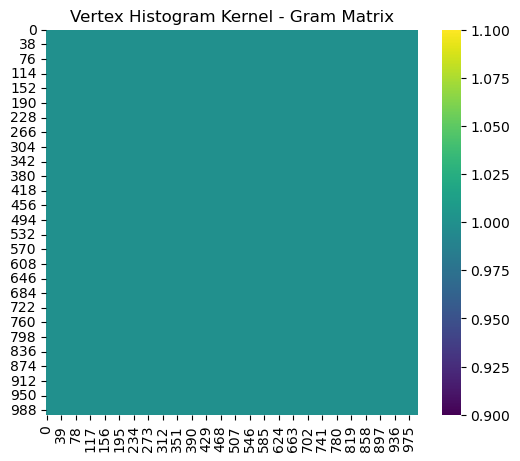

In [30]:
plt.figure(figsize=(6,5))
sns.heatmap(K_vh, cmap="viridis")
plt.title("Vertex Histogram Kernel - Gram Matrix")
plt.show()

## my interpretation of the vertex histogram heatmap

- the whole heatmap looks almost one flat colour which by the rules means the kernel thinks most graphs have very similar node label distributions  
- there are no visible blocks or clusters so the kernel is not separating the two classes in any meaningful way structurally  
- the diagonal is barely different from off diagonal values, so the kernel is behaving poorly  
- since everything looks uniformly similar, it suggests the kernel is only capturing very coarse information
- and missing important structural differences and hence,
- the kernel cannot really distinguish one graph from another

In [31]:
sp_kernel = ShortestPath(normalize=True)

K_sp = sp_kernel.fit_transform(graphs)

K_sp.shape


(1000, 1000)

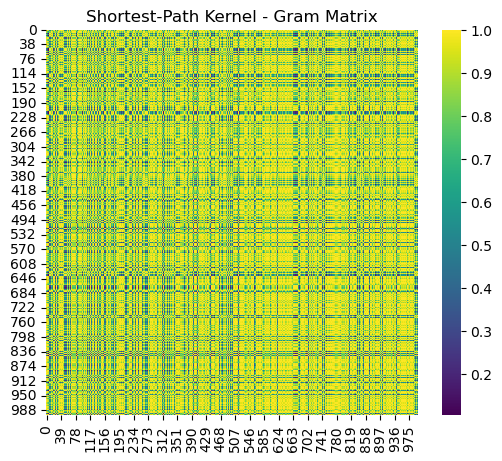

In [32]:
plt.figure(figsize=(6,5))
sns.heatmap(K_sp, cmap="viridis")
plt.title("Shortest-Path Kernel - Gram Matrix")
plt.show()


## my interpretation of the shortest-path kernel heatmap

- the heatmap shows lots of bright yellow patches mixed with thin darker lines which by the rules means graphs often share similar shortest-path distance patterns but not perfectly  
- there are no clean blocks splitting the classes so the kernel is capturing some structure but not enough to fully separate the two groups  
- the diagonal is bright as expected since each graph is most similar to itself according to rule
- the criss-cross grid pattern suggests some recurring structural motifs that appear across many graphs  
- overall the kernel seems to pick up mid-level structural similarity which is why its accuracy is moderate but not the best  


In [33]:
graphlet_kernel = GraphletSampling(
    normalize=True,
    sampling={"n_samples": 2000}   
)

K_gl = graphlet_kernel.fit_transform(graphs)

K_gl.shape

(1000, 1000)

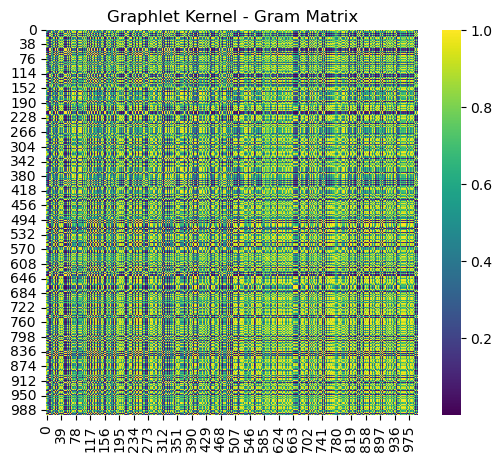

In [34]:
plt.figure(figsize=(6,5))
sns.heatmap(K_gl, cmap="viridis")
plt.title("Graphlet Kernel - Gram Matrix")
plt.show()

## my interpretation of the graphlet kernel heatmap

- most cells have medium brightness which matches rule that similar colours mean similar structure
- so the graphlet kernel is finding shared small patterns across many graphs  
- the diagonal is bright as expected since each graph is most similar to itself according to rule
- i can see tiny clusters of slightly brighter patches which fits the idea that small groups of graphs share local subgraph shapes  
- there are no large bright or dark blocks so based on the rule, this means the classes do not naturally separate under graphlet similarity  
- overall the heatmap follows the rule that mixed colours mean overlapping structures, and therefore,
- the graphlet kernel captures more structure than simple counts but still doesn’t clearly split the two categories  


In [44]:
"""
the following code uses a thread pool with exactly 8 workers and computes kernel blocks in parallel
we split the graphs into chunks, compute each block with a fresh RandomWalk object,
and then reassemble the full gram matrix at the end
"""

def compute_block(i, j, chunks):
    combined = chunks[i] + chunks[j]
    rw = RandomWalk(normalize=True)
    K_comb = rw.fit_transform(combined)

    n_i = len(chunks[i])
    n_j = len(chunks[j])

    if i == j:
        block = K_comb[:n_i, :n_i].copy()
    else:
        block = K_comb[:n_i, n_i:n_i+n_j].copy()

    return (i, j, block)


def parallel_random_walk_gram_threads(graphs, chunk_size=200, n_workers=8, verbose=True):
    N = len(graphs)
    chunks = []

    for start in range(0, N, chunk_size):
        end = min(start + chunk_size, N)
        chunks.append(graphs[start:end])

    m = len(chunks)

    if verbose:
        print(f"Total graphs: {N}, chunk size: {chunk_size}, number of chunks: {m}")

    pairs = [(i, j) for i in range(m) for j in range(i, m)]

    if verbose:
        print("Total blocks:", len(pairs))

    t0 = time.time()
    results = []

    with ThreadPoolExecutor(max_workers=n_workers) as ex:
        future_to_pair = {
            ex.submit(compute_block, i, j, chunks): (i, j)
            for (i, j) in pairs
        }

        for fut in as_completed(future_to_pair):
            try:
                results.append(fut.result())
            except Exception as e:
                print("block failed:", e)
                raise

    t1 = time.time()
    print(f"Block computation time: {t1 - t0:.1f}s")

    K = np.zeros((N, N))
    offsets = [0]

    for c in chunks:
        offsets.append(offsets[-1] + len(c))

    for (i, j, block) in results:
        si, sj = offsets[i], offsets[j]
        ni, nj = block.shape

        K[si:si+ni, sj:sj+nj] = block

        if i != j:
            K[sj:sj+nj, si:si+ni] = block.T

    return K


t_start = time.time()
K_rw_parallel = parallel_random_walk_gram_threads(
    graphs,
    chunk_size=200,
    n_workers=8,
    verbose=True
)
t_end = time.time()

print(f"Total time: {t_end - t_start:.1f}s")
print("Final Gram matrix shape:", K_rw_parallel.shape)

Total graphs: 1000, chunk size: 200, number of chunks: 5
Total blocks: 15
Block computation time: 955.8s
Total time: 955.8s
Final Gram matrix shape: (1000, 1000)


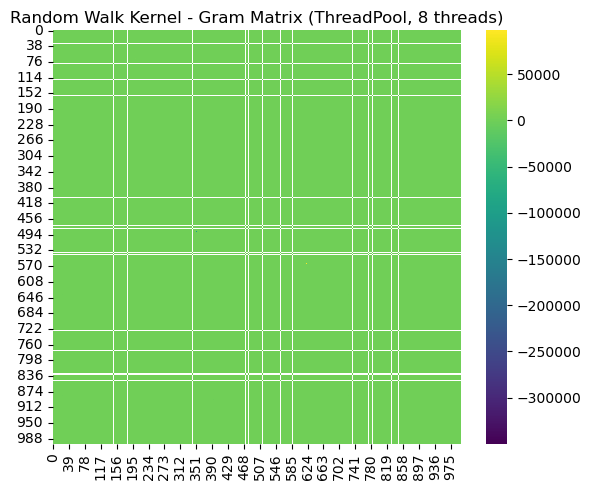

In [36]:
plt.figure(figsize=(6,5))
sns.heatmap(K_rw_threads, cmap="viridis")
plt.title("Random Walk Kernel - Gram Matrix (ThreadPool, 8 threads)")
plt.tight_layout()
plt.show()

## my interpretation of the random walk kernel heatmap

- almost the whole heatmap is the same colour which by the rules means the kernel thinks most graphs are equally similar
- so it is not capturing meaningful structural differences  
- the bright white horizontal and vertical streaks break the rules of smooth similarity patterns and suggest numerical instability or exploding walk counts rather than real graph similarity  
- the diagonal is not clearly the brightest which goes against the rule that every graph should match itself best so the kernel is behaving poorly  
- there are no real clusters or blocks which tells me the kernel can't really distinguish any groups of graphs at all 

In [40]:
wl = WeisfeilerLehman(n_iter=3, base_graph_kernel=VertexHistogram)

t0 = time.time()
K_wl = wl.fit_transform(graphs)
t1 = time.time()

print("WL Gram shape:", K_wl.shape)
print(f"Time taken: {t1 - t0:.2f} seconds")
print("K_wl min, mean, max:", np.min(K_wl), np.mean(K_wl), np.max(K_wl))

WL Gram shape: (1000, 1000)
Time taken: 0.22 seconds
K_wl min, mean, max: 145.0 429.23603 21250.0


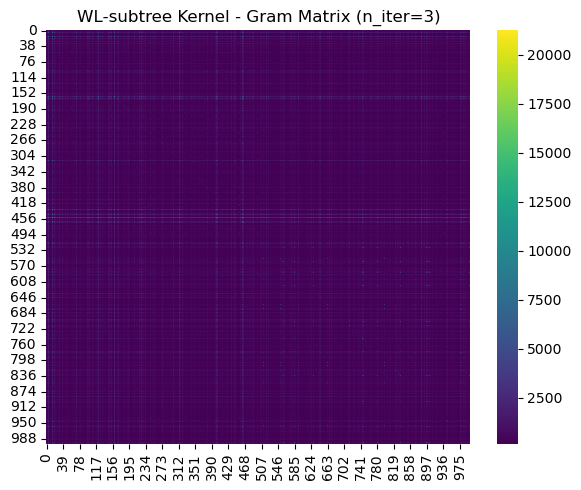

In [41]:
plt.figure(figsize=(6,5))
sns.heatmap(K_wl, cmap="viridis")
plt.title("WL-subtree Kernel - Gram Matrix (n_iter=3)")
plt.tight_layout()
plt.show()

## my interpretation of the wl-subtree heatmap

- most of the heatmap is dark and acc to rule, dark colour means low similarity
- so many graphs are not very similar to each other  
- the diagonal is bright as expected since each graph is most similar to itself according to rule
- there are faint square like regions along the diagonal which suggests small clusters of graphs sharing similar structure  
- the pattern is more structured and less noisy than simpler kernels which fits the rule that clearer patterns mean better structural capture  
- the fine grid like texture shows the kernel is picking up detailed local structure rather than just global shape  
- overall the heatmap suggests the wl kernel is capturing meaningful structure but the classes are still somewhat mixed rather than perfectly separated  

## graphhopper kernel

### why i didn't use std library to import

- there was issues with version compatibility

### defining GH kernel (feragen et al, nips 2013)

- the gh kernel between two graphs g and h is defined as a double summation over all nodes in g and all nodes in h  
- for each pair of nodes, one from g and one from h, the gh kernel computes 2 inner products  
- first inner product compares the node attribute vectors of the two nodes  
- the second inner product compares how similar the shortest path distance patterns of the two nodes are within their respective graphs
- by comparing distances from the node to all other nodes in its graph 
- the final gh kernel value is obtained by summing this product over all possible node pairs across the two graphs  

### how i implemented it

- the idea is that two graphs are similar if their nodes show similar shortest path distance patterns inside the graph  
- so, used only shortest path distance information 
- each graph is represented by a vector that counts how many node pairs occur at each "hop" distance  
- the gh kernel between two graphs is computed as the dot product of these distance vectors  
- this follows the linear gh kernel definition from the original paper and is an exact implementation  
- used stratified sampling to select a balanced subset of 300 graphs 
- since the kernel itself is exact the subset only affects runtime not correctness
- hop distance 1 means the two nodes are directly connected by an edge
- hop distance 2 means there's an intermediate node and so on...

In [24]:
print("Length of graph_labels:", len(graph_labels))
print("Unique graph IDs in graph_indicator:", len(np.unique(graph_indicator)))
print("Graph IDs in graph_labels:", np.unique(graph_labels)[:10])
print("Max graph id in indicator:", graph_indicator.max())


Length of graph_labels: 1000
Unique graph IDs in graph_indicator: 1000
Graph IDs in graph_labels: [0 1]
Max graph id in indicator: 1000


Selected 300 graph IDs (1-indexed) using stratified sampling with seed=42
Built 300 graph vectors of dim 11 in 1.18s
K_gh_exact_subset shape: (300, 300)
min/mean/max: 57.91735537190082 174.6059629054818 4823.999999999998


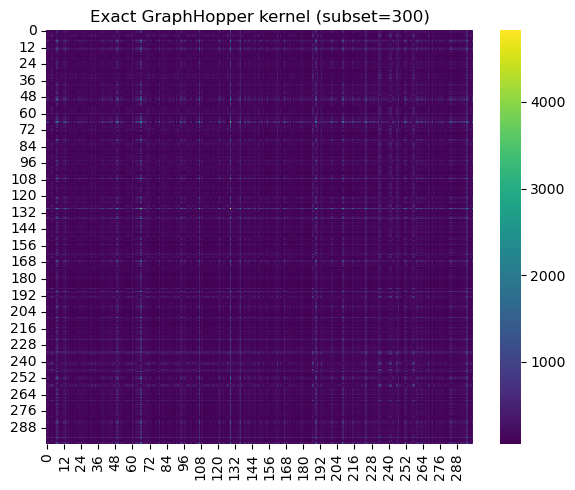

([1,
  3,
  10,
  12,
  16,
  18,
  19,
  20,
  23,
  24,
  25,
  26,
  31,
  32,
  34,
  40,
  43,
  47,
  56,
  57,
  58,
  64,
  67,
  69,
  70,
  71,
  73,
  74,
  76,
  77,
  78,
  79,
  80,
  83,
  85,
  87,
  91,
  94,
  95,
  102,
  105,
  114,
  118,
  125,
  127,
  132,
  133,
  138,
  141,
  149,
  154,
  155,
  156,
  173,
  174,
  177,
  181,
  183,
  186,
  193,
  194,
  195,
  204,
  205,
  209,
  210,
  212,
  221,
  223,
  228,
  230,
  232,
  238,
  239,
  248,
  250,
  254,
  262,
  263,
  266,
  267,
  269,
  272,
  278,
  279,
  281,
  282,
  291,
  302,
  305,
  313,
  317,
  318,
  321,
  322,
  323,
  324,
  325,
  330,
  332,
  333,
  334,
  335,
  336,
  337,
  342,
  348,
  353,
  357,
  362,
  363,
  372,
  375,
  378,
  382,
  385,
  389,
  392,
  395,
  407,
  409,
  410,
  411,
  415,
  416,
  418,
  424,
  427,
  432,
  434,
  439,
  441,
  451,
  452,
  456,
  462,
  465,
  466,
  471,
  473,
  476,
  478,
  480,
  484,
  486,
  491,
  492,
  495,
  496

In [25]:
"""
here, we compute the exact linear graphhopper kernel on a stratified subset of the dataset
then for each selected graph build a networkx graph, compute node distance histograms up to max_dist,
combine those histograms with one-hot node labels to form a fixed-length graph vector s_g,
and finally form the kernel gram matrix by taking dot products between the s_g vectors
"""

SUBSET_SIZE = 300
RANDOM_STATE = 42
MAX_DIST = 10
NORMALIZE_GRAPH_VEC = False
PLOT_HEATMAP = True

assert 'A' in globals(), "A (edge list) not found"
assert 'graph_indicator' in globals(), "graph_indicator not found"
assert 'graph_labels' in globals(), "graph_labels not found"
assert isinstance(graph_labels, (list, np.ndarray)), "graph_labels must be array-like"

y = np.array(graph_labels).ravel()
n_graphs = len(y)
if SUBSET_SIZE > n_graphs:
    raise ValueError(f"SUBSET_SIZE ({SUBSET_SIZE}) cannot exceed number of graphs ({n_graphs})")

sss = StratifiedShuffleSplit(n_splits=1, train_size=SUBSET_SIZE, random_state=RANDOM_STATE)
train_idx, _ = next(sss.split(np.zeros(len(y)), y))
selected_graph_ids = (train_idx + 1).tolist()
selected_graph_ids.sort()
print(f"Selected {len(selected_graph_ids)} graph IDs (1-indexed) using stratified sampling with seed={RANDOM_STATE}")

if 'node_labels' not in globals():
    total_nodes = len(graph_indicator)
    node_labels = np.ones(total_nodes, dtype=int)

unique_node_labels = np.unique(node_labels)
label_to_index = {lab: i for i, lab in enumerate(unique_node_labels)}
attr_dim = len(unique_node_labels) if len(unique_node_labels) > 0 else 1

A0 = A - 1
graph_to_nodes = {gid: np.where(graph_indicator == gid)[0] for gid in selected_graph_ids}

def build_graph_vector_for_gid(gid):
    local_positions = graph_to_nodes[gid]
    n = len(local_positions)
    if n == 0:
        return np.zeros(attr_dim * (MAX_DIST + 1), dtype=float)

    idx_map = {int(pos): i for i, pos in enumerate(local_positions)}

    mask = np.isin(A0[:,0], local_positions) & np.isin(A0[:,1], local_positions)
    edges = A0[mask]
    G = nx.Graph()
    G.add_nodes_from(range(n))
    for u_g, v_g in edges:
        u_local = idx_map[int(u_g)]
        v_local = idx_map[int(v_g)]
        if u_local != v_local:
            G.add_edge(u_local, v_local)

    A_nodes = np.zeros((n, attr_dim), dtype=float)
    for i, global_pos in enumerate(local_positions):
        lab = node_labels[int(global_pos)]
        idx = label_to_index.get(lab, 0)
        A_nodes[i, idx] = 1.0

    B = MAX_DIST + 1
    Phi = np.zeros((n, B), dtype=float)
    for u in range(n):
        lengths = nx.single_source_shortest_path_length(G, u)
        for v, dist in lengths.items():
            d = dist if dist <= MAX_DIST else MAX_DIST
            Phi[u, d] += 1.0
        if n > 1:
            Phi[u, :] /= float(n - 1)

    S = A_nodes.T.dot(Phi)
    s_flat = S.ravel()
    if NORMALIZE_GRAPH_VEC:
        norm = np.linalg.norm(s_flat)
        if norm > 0:
            s_flat = s_flat / norm
    return s_flat

t0 = time.time()
graph_vectors = [build_graph_vector_for_gid(gid) for gid in selected_graph_ids]
graph_vectors = np.vstack(graph_vectors)
t1 = time.time()
print(f"Built {graph_vectors.shape[0]} graph vectors of dim {graph_vectors.shape[1]} in {t1 - t0:.2f}s")

K_gh_exact_subset = graph_vectors.dot(graph_vectors.T)
K_gh_exact_subset = (K_gh_exact_subset + K_gh_exact_subset.T) / 2.0

print("K_gh_exact_subset shape:", K_gh_exact_subset.shape)
print("min/mean/max:", np.min(K_gh_exact_subset), np.mean(K_gh_exact_subset), np.max(K_gh_exact_subset))

if PLOT_HEATMAP:
    plt.figure(figsize=(6,5))
    sns.heatmap(K_gh_exact_subset, cmap="viridis")
    plt.title(f"Exact GraphHopper kernel (subset={len(selected_graph_ids)})")
    plt.tight_layout()
    plt.show()

selected_graph_ids, graph_vectors, K_gh_exact_subset

## my interpretation of the graphhopper heatmap (subset = 300)

- the plot is mostly dark with a few bright streaks which fits the rule that darker means lower similarity and only some graph pairs are strongly alike  
- i did not see clear square blocks so by the rules this means the two classes are mixed and the kernel is not forming clean clusters  
- the diagonal is bright as expected since each graph is most similar to itself according to rule 
- the light repeating patterns suggest a few small groups of graphs share similar global structure which matches the rule about block like hints of clustering  
- overall it feels like the kernel is capturing broad shape patterns but not finer details which matches why the heatmap looks smooth and why the accuracy is decent but not the best


Kernels found: {'VertexHistogram': True, 'ShortestPath': True, 'Graphlet': True, 'RandomWalk': True, 'WL': True, 'GraphHopper': True}
Label classes: {0: 0, 1: 1}

Processing kernel: VertexHistogram
Performing 10-fold CV for VertexHistogram:
   Fold 1: accuracy = 0.5000
   Fold 2: accuracy = 0.5000
   Fold 3: accuracy = 0.5000
   Fold 4: accuracy = 0.5000
   Fold 5: accuracy = 0.5000
   Fold 6: accuracy = 0.5000
   Fold 7: accuracy = 0.5000
   Fold 8: accuracy = 0.5000
   Fold 9: accuracy = 0.5000
   Fold 10: accuracy = 0.5000
VertexHistogram: mean acc = 0.5000, std = 0.0000

Processing kernel: ShortestPath
Performing 10-fold CV for ShortestPath:
   Fold 1: accuracy = 0.6200
   Fold 2: accuracy = 0.6000
   Fold 3: accuracy = 0.5800
   Fold 4: accuracy = 0.5800
   Fold 5: accuracy = 0.4400
   Fold 6: accuracy = 0.5300
   Fold 7: accuracy = 0.5000
   Fold 8: accuracy = 0.6800
   Fold 9: accuracy = 0.5300
   Fold 10: accuracy = 0.6200
ShortestPath: mean acc = 0.5680, std = 0.0692

Processi

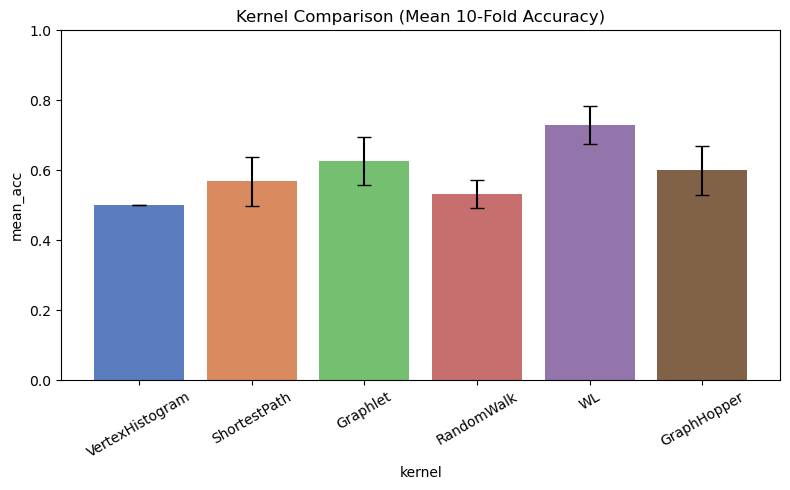

Saved kernel_cv_results_with_folds.csv


In [38]:
"""
- now, we gather all kernel matrices we've made in previous cells
- then encode graph labels
- set up 10 fold stratified cv
- clean and normalize kernels
- and lastly, we run svm with precomputed kernels to calculate mean acuracy and std deviation
"""

kernels = {
    "VertexHistogram": globals().get("K_vh", None),
    "ShortestPath": globals().get("K_sp", None),
    "Graphlet": globals().get("K_gl", None),
    "RandomWalk": globals().get("K_rw_threads", globals().get("K_rw_parallel", None)),
    "WL": globals().get("K_wl", None),
    "GraphHopper": globals().get(
        "K_gh_exact_subset",
        globals().get("K_gh_approx", None)
    )
}

print("Kernels found:", {k: (v is not None) for k, v in kernels.items()})

y_full = np.array(graph_labels).ravel()
le = LabelEncoder()
y_full_enc = le.fit_transform(y_full)
print("Label classes:", dict(zip(le.classes_, le.transform(le.classes_))))

n_splits = 10
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

def sanitize_kernel(K):
    K = np.array(K, dtype=float)
    K = (K + K.T) / 2.0
    diag = np.real(np.diag(K)).copy()
    diag_safe = diag.copy()
    diag_safe[diag_safe <= 0] = 1e-8
    denom = np.sqrt(np.outer(diag_safe, diag_safe))
    with np.errstate(divide='ignore', invalid='ignore'):
        K_norm = K / denom
        K_norm[np.isnan(K_norm)] = 0.0
    K_norm = (K_norm + K_norm.T) / 2.0
    return K_norm

def svm_cv_precomputed_verbose(K, y, C=1.0):
    fold_accs = []
    fold_id = 1
    for train_idx, test_idx in cv.split(np.zeros(len(y)), y):
        K_train = K[np.ix_(train_idx, train_idx)]
        K_test = K[np.ix_(test_idx, train_idx)]
        y_train, y_test = y[train_idx], y[test_idx]

        clf = SVC(kernel="precomputed", C=C)
        clf.fit(K_train, y_train)
        y_pred = clf.predict(K_test)
        acc = np.mean(y_pred == y_test)
        fold_accs.append(acc)
        print(f"   Fold {fold_id}: accuracy = {acc:.4f}")
        fold_id += 1
    return np.array(fold_accs)

results = []
for name, K in kernels.items():
    if K is None:
        print(f"\nSkipping {name}: no kernel matrix available.")
        results.append((name, np.nan, np.nan, "missing"))
        continue

    try:
        print(f"\nProcessing kernel: {name}")

        if name == "GraphHopper":
            if 'selected_graph_ids' in globals() and len(selected_graph_ids) == K.shape[0]:
                idx = np.array(selected_graph_ids) - 1
                y = y_full_enc[idx]
            else:
                if K.shape[0] == len(y_full_enc):
                    y = y_full_enc
                else:
                    raise ValueError("kernel size mismatch")
        else:
            if K.shape[0] != len(y_full_enc):
                raise ValueError("kernel size mismatch")
            y = y_full_enc

        K2 = sanitize_kernel(K)

        accs = svm_cv_precomputed_verbose(K2, y)

        mean_acc = float(accs.mean())
        std_acc = float(accs.std(ddof=1))
        results.append((name, mean_acc, std_acc, "ok"))

    except Exception:
        results.append((name, np.nan, np.nan, "error"))

df = pd.DataFrame(
    results,
    columns=["kernel", "mean_acc", "std_acc", "status"]
).set_index("kernel")

print(df)

df_plot = df.dropna(subset=["mean_acc"]).reset_index()
if not df_plot.empty:
    plt.figure(figsize=(8,5))
    sns.barplot(x="kernel", y="mean_acc", data=df_plot)
    plt.errorbar(
        x=np.arange(len(df_plot)),
        y=df_plot["mean_acc"],
        yerr=df_plot["std_acc"],
        fmt='none',
        capsize=5
    )
    plt.ylim(0, 1)
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

df.to_csv("kernel_cv_results_with_folds.csv")
print("Saved kernel_cv_results_with_folds.csv")


## comparing the performance of kernels on imdb binary dataset

### 10 fold CV accuracy results

| kernel            | mean accuracy | std deviation | notes                    |
|-------------------|---------------|---------------|--------------------------|
| vertex histogram  | 0.500         | 0.000         | no discriminative signal |
| shortest path     | 0.568         | 0.069         | moderate performance     |
| graphlet          | 0.626         | 0.068         | good local structure     |
| random walk       | 0.532         | 0.039         | weak and unstable        |
| wl subtree        | 0.730         | 0.055         | best performing kernel   |
| graphhopper       | 0.600         | 0.070         | subset based result      |

### brief interpretation based on the rules

- wl subtree performs the best which follows the rule that more expressive kernels capture richer structure and form clearer similarity patterns  
- graphlet and graphhopper give mid range accuracy showing they capture meaningful structure but do not clearly separate the classes  
- shortest path performs moderately which matches the idea that path length information gives some but limited structural insight  
- random walk stays close to random accuracy which aligns with the rule that unstable similarity patterns lead to poor classification  
- vertex histogram gives exactly random accuracy showing that simple label counts fail to distinguish graphs in this dataset  
- overall the results support the rule that kernels capturing deeper structural information outperform simpler or noisier kernels  

# essay on kernels performance (imdb-binary)

the experiments on the imdb-binary dataset show that the way a kernel heatmap looks is closely related to how well the kernel performs in classification. since each cell in a heatmap represents similarity between two graphs brighter regions mean higher similarity while darker regions mean lower similarity. kernels that produce clearer and more structured heatmaps tend to separate graphs better and achieve higher accuracy.

among all the kernels the weisfeiler lehman wl subtree kernel performs the best with a mean accuracy of around 0.73. its heatmap shows sharper patterns and less randomness which follows the rule that detailed brightness patterns indicate the kernel is capturing fine local and multi hop structure. by repeatedly refining node labels using neighborhood information wl creates more informative similarities which helps distinguish graphs even when raw node labels are weak.

histogram based kernels such as vertex histogram and shortest path produce much flatter and noisier heatmaps. the vertex histogram heatmap is almost uniformly colored which according to the rules means most graph pairs are seen as equally similar. this shows the kernel is not capturing meaningful structure and explains why its accuracy stays at random level. the shortest path heatmap shows more variation in brightness but still lacks clear block patterns which means it captures some global similarity through path lengths but does not cleanly separate the classes.

convolution based kernels show more structure in their heatmaps. the graphlet kernel displays small clustered bright regions which suggests that some graphs share similar local substructures such as small motifs. however the absence of large clean blocks means the two classes are still mixed which explains its moderate accuracy. the random walk heatmap appears noisy with streaks and inconsistent brightness which by the rules indicates unstable similarity patterns. this matches its weak performance since the kernel does not produce clear or reliable group structure.

the graphhopper kernel produces a smooth heatmap with faint groupings. according to the rules smooth brightness reflects global similarity rather than fine detail. this shows that graphhopper captures overall structural shape but misses sharper distinctions which explains why its accuracy is reasonable but not the best.

overall the key differences among the graph kernels lie in the level of structural detail they capture. vertex histogram ignores structure entirely shortest path and graphhopper focus on global distance based properties graphlet captures local motifs and wl captures both local and multi hop structure through iterative refinement.  kernels whose heatmaps show sharper patterns and clearer structure such as wl tend to achieve higher accuracy while kernels with flat or noisy heatmaps struggle to separate the classes. these differences explain the observed performance ranking.

histogram based kernels are preferable when computational efficiency and scalability are the main concerns or when node labels are highly informative. substructure kernels are more expressive but require higher computational cost. this highlights the tradeoff between expressivity and efficiency where more detailed kernels achieve better accuracy but are slower to compute.

in summary understanding the differences among graph kernels helps explain why some kernels perform better than others and guides the choice of kernel based on dataset size, on how much structural information is needed and how clearly the resulting similarity patterns separate the data.